<a href="https://colab.research.google.com/github/batinylmz/financialAnomalyDetection/blob/yunusMaster/finance_LOF_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Gerekli kütüphaneleri yükle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (roc_auc_score, precision_recall_curve, auc,
                             f1_score, confusion_matrix, classification_report,
                             precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
import warnings
import time
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Kütüphaneler yüklendi!")
print("🎯 Veri Sızıntısını Önleyen Benchmark Pipeline'ı hazırlanıyor...")



✅ Kütüphaneler yüklendi!
🎯 Veri Sızıntısını Önleyen Benchmark Pipeline'ı hazırlanıyor...


In [ ]:
# Veriyi yükle
# Google Colab'da: Sol panelden Files > Upload ile dosyayı yükle

df = pd.read_csv('/content/drive/MyDrive/financial_anomaly_benchmark_data.csv')

# Tarih sütununu datetime'a çevir
date_columns = ['timestamp', 'date', 'Datetime', 'Date', 'time', 'Time']
for col in date_columns:
    if col in df.columns:
        df['timestamp'] = pd.to_datetime(df[col])
        break

# Eğer timestamp yoksa, indeks bazlı oluştur
if 'timestamp' not in df.columns:
    print("⚠️  Timestamp sütunu bulunamadı, sentetik tarih oluşturuluyor...")
    # 15 dakikalık BTC/USDT verisi varsayımı
    start_date = pd.Timestamp('2023-01-01')
    df['timestamp'] = pd.date_range(start=start_date, periods=len(df), freq='15min')

df = df.sort_values('timestamp').reset_index(drop=True)

print("📊 Veri Seti Bilgileri:")
print(f"Satır sayısı: {len(df):,}")
print(f"Tarih aralığı: {df['timestamp'].min()} - {df['timestamp'].max()}")
print(f"\nSütunlar: {df.columns.tolist()}")
print(f"\nİlk 5 satır:")
print(df.head())
print(f"\nVeri tipleri:")
print(df.dtypes)


⚠️  Timestamp sütunu bulunamadı, sentetik tarih oluşturuluyor...
📊 Veri Seti Bilgileri:
Satır sayısı: 141,005
Tarih aralığı: 2023-01-01 00:00:00 - 2027-01-08 19:00:00

Sütunlar: ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'Returns', 'Volume_Change', 'Volatility_HighLow', 'timestamp']

İlk 5 satır:
             Timestamp      Open      High       Low     Close     Volume  \
0  2022-01-01 00:00:00  46216.93  46527.26  46208.37  46332.51  386.65709   
1  2022-01-01 00:15:00  46332.52  46421.27  46236.27  46375.42  319.99973   
2  2022-01-01 00:30:00  46375.42  46689.42  46360.19  46610.81  386.08077   
3  2022-01-01 00:45:00  46610.81  46731.39  46575.76  46656.13  410.59336   
4  2022-01-01 01:00:00  46656.14  46767.24  46574.06  46766.99  330.08774   

    Returns  Volume_Change  Volatility_HighLow           timestamp  
0  0.000000       0.000000            0.006901 2023-01-01 00:00:00  
1  0.000926      -0.172394            0.004001 2023-01-01 00:15:00  
2  0.005076       0

In [ ]:
def create_ground_truth_labels(df, window_months=3, percentile_threshold=99):
    """
    Volume_Change ve Volatility_HighLow bazlı ground truth etiketleri oluşturur.

    KRİTİK: Bu sütunlar daha sonra eğitim setinden silinecek!

    Parameters:
    -----------
    df : DataFrame
        Orijinal veri seti
    window_months : int
        Pencere boyutu (ay)
    percentile_threshold : float
        Anomali için yüzdelik dilim (99 = en üst %1)

    Returns:
    --------
    df_labeled : DataFrame
        ground_truth sütunu eklenmiş veri
    labeling_features : list
        Etiketleme için kullanılan sütunlar (sonra silinecek)
    """
    df_labeled = df.copy()

    # Etiketleme için kullanılacak sütunları bul
    labeling_features = []

    # Volume_Change sütununu bul veya oluştur
    volume_cols = [col for col in df.columns if 'volume' in col.lower()]
    if len(volume_cols) > 0:
        volume_col = volume_cols[0]
        if 'volume_change' not in df.columns.str.lower():
            df_labeled['Volume_Change'] = df_labeled[volume_col].pct_change().fillna(0)
            labeling_features.append('Volume_Change')
        else:
            vol_change_col = [col for col in df.columns if 'volume_change' in col.lower()][0]
            labeling_features.append(vol_change_col)

    # Volatility_HighLow sütununu bul veya oluştur
    if 'high' in df.columns.str.lower() and 'low' in df.columns.str.lower():
        high_col = [col for col in df.columns if col.lower() == 'high'][0]
        low_col = [col for col in df.columns if col.lower() == 'low'][0]
        close_col = [col for col in df.columns if col.lower() == 'close'][0]

        df_labeled['Volatility_HighLow'] = (df_labeled[high_col] - df_labeled[low_col]) / df_labeled[close_col]
        labeling_features.append('Volatility_HighLow')

    # Eğer gerekli sütunlar yoksa, mevcut sütunlardan en uygun olanları seç
    if len(labeling_features) == 0:
        print("⚠️  Volume_Change ve Volatility_HighLow bulunamadı, alternatif sütunlar kullanılıyor...")
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'timestamp' in numeric_cols:
            numeric_cols.remove('timestamp')
        labeling_features = numeric_cols[:2]  # İlk 2 numerik sütunu kullan

    print(f"🏷️  Etiketleme için kullanılan sütunlar: {labeling_features}")

    # 3 aylık bloklara ayır ve etiketle
    df_labeled['ground_truth'] = 0

    start_date = df_labeled['timestamp'].min()
    end_date = df_labeled['timestamp'].max()
    current_date = start_date

    block_count = 0
    total_anomalies = 0

    while current_date < end_date:
        window_end = current_date + pd.DateOffset(months=window_months)

        # Bu bloğa ait verileri bul
        mask = (df_labeled['timestamp'] >= current_date) & (df_labeled['timestamp'] < window_end)
        block_indices = df_labeled[mask].index

        if len(block_indices) > 0:
            block_count += 1

            # Her bir labeling feature için en üst %1'i bul
            anomaly_mask = np.zeros(len(block_indices), dtype=bool)

            for feature in labeling_features:
                if feature in df_labeled.columns:
                    feature_values = df_labeled.loc[block_indices, feature].values
                    threshold = np.percentile(feature_values, percentile_threshold)
                    anomaly_mask |= (feature_values >= threshold)

            # Anomalileri işaretle
            anomaly_indices = block_indices[anomaly_mask]
            df_labeled.loc[anomaly_indices, 'ground_truth'] = 1

            n_anomalies = len(anomaly_indices)
            total_anomalies += n_anomalies

            print(f"  Blok {block_count}: {current_date.date()} - {window_end.date()} | "
                  f"Toplam: {len(block_indices)}, Anomali: {n_anomalies} ({n_anomalies/len(block_indices)*100:.2f}%)")

        current_date = window_end

    print(f"\n✅ Etiketleme tamamlandı!")
    print(f"📊 Toplam {block_count} blok işlendi")
    print(f"🎯 Toplam anomali sayısı: {total_anomalies} ({total_anomalies/len(df_labeled)*100:.2f}%)")
    print(f"\n⚠️  KRİTİK: {labeling_features} sütunları eğitim setinden silinecek!")

    return df_labeled, labeling_features

# Ground truth etiketlerini oluştur
df_labeled, labeling_features = create_ground_truth_labels(df, window_months=3, percentile_threshold=99)

# Etiket dağılımını göster
print("\n📊 Ground Truth Dağılımı:")
print(df_labeled['ground_truth'].value_counts())
print(f"Anomali oranı: {df_labeled['ground_truth'].mean()*100:.2f}%")


🏷️  Etiketleme için kullanılan sütunlar: ['Volume_Change', 'Volatility_HighLow']
  Blok 1: 2023-01-01 - 2023-04-01 | Toplam: 8640, Anomali: 150 (1.74%)
  Blok 2: 2023-04-01 - 2023-07-01 | Toplam: 8736, Anomali: 164 (1.88%)
  Blok 3: 2023-07-01 - 2023-10-01 | Toplam: 8832, Anomali: 151 (1.71%)
  Blok 4: 2023-10-01 - 2024-01-01 | Toplam: 8832, Anomali: 163 (1.85%)
  Blok 5: 2024-01-01 - 2024-04-01 | Toplam: 8736, Anomali: 157 (1.80%)
  Blok 6: 2024-04-01 - 2024-07-01 | Toplam: 8736, Anomali: 146 (1.67%)
  Blok 7: 2024-07-01 - 2024-10-01 | Toplam: 8832, Anomali: 154 (1.74%)
  Blok 8: 2024-10-01 - 2025-01-01 | Toplam: 8832, Anomali: 152 (1.72%)
  Blok 9: 2025-01-01 - 2025-04-01 | Toplam: 8640, Anomali: 161 (1.86%)
  Blok 10: 2025-04-01 - 2025-07-01 | Toplam: 8736, Anomali: 152 (1.74%)
  Blok 11: 2025-07-01 - 2025-10-01 | Toplam: 8832, Anomali: 165 (1.87%)
  Blok 12: 2025-10-01 - 2026-01-01 | Toplam: 8832, Anomali: 166 (1.88%)
  Blok 13: 2026-01-01 - 2026-04-01 | Toplam: 8640, Anomali: 157 

In [ ]:
def prepare_training_features(df, labeling_features, keep_ground_truth=True):
    """
    Eğitim için özellikleri hazırlar ve veri sızıntısını önler.

    KRİTİK: Etiketleme için kullanılan sütunları SİLER!

    Parameters:
    -----------
    df : DataFrame
        Etiketlenmiş veri seti
    labeling_features : list
        Silinecek sütunlar (Volume_Change, Volatility_HighLow)
    keep_ground_truth : bool
        ground_truth sütununu sakla (benchmark için gerekli)

    Returns:
    --------
    df_clean : DataFrame
        Temizlenmiş veri seti
    feature_columns : list
        Model için kullanılacak özellikler
    """
    df_clean = df.copy()

    print("🚫 VERİ SIZINTISI ÖNLENİYOR...")
    print("=" * 80)

    # Etiketleme sütunlarını sil
    columns_to_drop = []
    for col in labeling_features:
        if col in df_clean.columns:
            columns_to_drop.append(col)
            print(f"  ❌ SİLİNİYOR: {col}")

    df_clean = df_clean.drop(columns=columns_to_drop)

    print(f"\n✅ {len(columns_to_drop)} sütun silindi!")
    print("=" * 80)

    # Model için kullanılacak özellikleri belirle
    # Sadece temel fiyat hareketleri: Open, High, Low, Close, Returns vb.
    exclude_cols = ['timestamp', 'ground_truth', 'date', 'Date', 'Datetime', 'time', 'Time']

    feature_columns = []
    for col in df_clean.columns:
        if col not in exclude_cols and df_clean[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            feature_columns.append(col)

    # Returns sütunu yoksa oluştur
    if 'Returns' not in df_clean.columns and 'returns' not in df_clean.columns:
        close_cols = [col for col in df_clean.columns if col.lower() == 'close']
        if len(close_cols) > 0:
            df_clean['Returns'] = df_clean[close_cols[0]].pct_change().fillna(0)
            feature_columns.append('Returns')
            print("  ➕ Returns sütunu oluşturuldu")

    print(f"\n🎯 Model için kullanılacak özellikler ({len(feature_columns)} adet):")
    for i, col in enumerate(feature_columns, 1):
        print(f"  {i}. {col}")

    print("\n💡 Model sadece bu temel fiyat hareketlerini görecek!")
    print("   Volume_Change ve Volatility_HighLow bilgisi YOK!")

    return df_clean, feature_columns

# Eğitim özelliklerini hazırla (VERİ SIZINTISINI ÖNLE!)
df_clean, training_features = prepare_training_features(df_labeled, labeling_features)

print("\n" + "=" * 80)
print("✅ VERİ HAZIR!")
print(f"📊 Temizlenmiş veri boyutu: {df_clean.shape}")
print(f"🎯 Eğitim özellikleri: {len(training_features)} sütun")
print(f"🏷️  Ground truth: {df_clean['ground_truth'].sum()} anomali")
print("=" * 80)



🚫 VERİ SIZINTISI ÖNLENİYOR...
  ❌ SİLİNİYOR: Volume_Change
  ❌ SİLİNİYOR: Volatility_HighLow

✅ 2 sütun silindi!

🎯 Model için kullanılacak özellikler (6 adet):
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume
  6. Returns

💡 Model sadece bu temel fiyat hareketlerini görecek!
   Volume_Change ve Volatility_HighLow bilgisi YOK!

✅ VERİ HAZIR!
📊 Temizlenmiş veri boyutu: (141005, 9)
🎯 Eğitim özellikleri: 6 sütun
🏷️  Ground truth: 2521 anomali


In [ ]:
def create_rolling_windows(df, window_months=3):
    """
    3 aylık rolling window'ları oluşturur.
    """
    df = df.sort_values('timestamp').reset_index(drop=True)

    start_date = df['timestamp'].min()
    end_date = df['timestamp'].max()

    windows = []
    current_date = start_date

    while current_date < end_date:
        window_end = current_date + pd.DateOffset(months=window_months)

        mask = (df['timestamp'] >= current_date) & (df['timestamp'] < window_end)
        window_df = df[mask]

        if len(window_df) > 50:  # Minimum veri kontrolü
            start_idx = window_df.index[0]
            end_idx = window_df.index[-1] + 1
            windows.append((start_idx, end_idx, current_date, window_end))

        current_date = window_end

    print(f"🔄 {len(windows)} adet 3 aylık pencere oluşturuldu\n")

    for i, (start, end, start_date, end_date) in enumerate(windows):
        n_anomalies = df.iloc[start:end]['ground_truth'].sum()
        print(f"  Pencere {i+1}: {start_date.date()} - {end_date.date()} | "
              f"Boyut: {end-start}, Anomali: {n_anomalies}")

    return windows

# Pencereleri oluştur
windows = create_rolling_windows(df_clean, window_months=3)


🔄 17 adet 3 aylık pencere oluşturuldu

  Pencere 1: 2023-01-01 - 2023-04-01 | Boyut: 8640, Anomali: 150
  Pencere 2: 2023-04-01 - 2023-07-01 | Boyut: 8736, Anomali: 164
  Pencere 3: 2023-07-01 - 2023-10-01 | Boyut: 8832, Anomali: 151
  Pencere 4: 2023-10-01 - 2024-01-01 | Boyut: 8832, Anomali: 163
  Pencere 5: 2024-01-01 - 2024-04-01 | Boyut: 8736, Anomali: 157
  Pencere 6: 2024-04-01 - 2024-07-01 | Boyut: 8736, Anomali: 146
  Pencere 7: 2024-07-01 - 2024-10-01 | Boyut: 8832, Anomali: 154
  Pencere 8: 2024-10-01 - 2025-01-01 | Boyut: 8832, Anomali: 152
  Pencere 9: 2025-01-01 - 2025-04-01 | Boyut: 8640, Anomali: 161
  Pencere 10: 2025-04-01 - 2025-07-01 | Boyut: 8736, Anomali: 152
  Pencere 11: 2025-07-01 - 2025-10-01 | Boyut: 8832, Anomali: 165
  Pencere 12: 2025-10-01 - 2026-01-01 | Boyut: 8832, Anomali: 166
  Pencere 13: 2026-01-01 - 2026-04-01 | Boyut: 8640, Anomali: 157
  Pencere 14: 2026-04-01 - 2026-07-01 | Boyut: 8736, Anomali: 152
  Pencere 15: 2026-07-01 - 2026-10-01 | Boyut:

In [ ]:
def optimize_k_for_window(X, y_true, k_range=range(20, 81, 5)):
    """
    PR-AUC metriğini kullanarak en iyi k parametresini bulur.
    """
    best_k = 20
    best_score = 0
    scores = []

    for k in k_range:
        try:
            if k >= len(X):
                continue

            lof = LocalOutlierFactor(n_neighbors=k, contamination=0.01, novelty=False)
            lof.fit_predict(X)
            lof_scores = -lof.negative_outlier_factor_

            if len(np.unique(y_true)) > 1:
                precision, recall, _ = precision_recall_curve(y_true, lof_scores)
                pr_auc = auc(recall, precision)
                scores.append((k, pr_auc))

                if pr_auc > best_score:
                    best_score = pr_auc
                    best_k = k
        except Exception as e:
            continue

    return best_k, best_score, scores

def calculate_optimal_threshold(y_true, y_scores):
    """
    F1-score'u maksimize eden threshold'u bulur.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
    return optimal_threshold, f1_scores[optimal_idx]

def run_leakage_free_lof_benchmark(df, feature_cols, windows, k_range=range(20, 81, 10)):
    """
    Veri sızıntısı olmayan LOF benchmark'ını çalıştırır.

    Model sadece fiyat hareketlerini görür, Volume/Volatility bilgisi YOK!
    """
    results = []
    all_predictions = {
        'indices': [],
        'y_true': [],
        'y_pred': [],
        'lof_scores': [],
        'window_id': [],
        'timestamp': []
    }

    print("\n" + "=" * 80)
    print("🚀 VERİ SIZINTISI OLMAYAN LOF BENCHMARK BAŞLIYOR")
    print("=" * 80)
    print("💡 Model sadece fiyat hareketlerini görecek!")
    print("🎯 Hedef: Volume/Volatility bazlı anomalileri fiyattan tahmin etmek\n")

    for window_id, (start_idx, end_idx, start_date, end_date) in enumerate(windows):
        print(f"\n{'='*80}")
        print(f"📊 Pencere {window_id + 1}/{len(windows)}")
        print(f"📅 Tarih: {start_date.date()} - {end_date.date()}")
        print(f"{'='*80}")

        # Pencere verisini al
        X_window = df.iloc[start_idx:end_idx][feature_cols].values
        y_true_window = df.iloc[start_idx:end_idx]['ground_truth'].values
        timestamps = df.iloc[start_idx:end_idx]['timestamp'].values

        print(f"  📏 Veri boyutu: {len(X_window)}")
        print(f"  🎯 Gerçek anomali sayısı: {y_true_window.sum()} ({y_true_window.mean()*100:.2f}%)")

        # Veriyi normalize et
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_window)

        # K optimizasyonu
        print(f"  🔍 K optimizasyonu yapılıyor...")
        best_k, best_pr_auc, k_scores = optimize_k_for_window(X_scaled, y_true_window, k_range)
        print(f"  ✅ En iyi k: {best_k} (PR-AUC: {best_pr_auc:.4f})")

        # LOF modelini eğit
        print(f"  🤖 LOF modeli eğitiliyor (k={best_k})...")
        start_time = time.time()

        lof = LocalOutlierFactor(n_neighbors=best_k, contamination=0.01, novelty=False)
        y_pred = lof.fit_predict(X_scaled)
        lof_scores = -lof.negative_outlier_factor_

        inference_time_ms = (time.time() - start_time) * 1000
        print(f"  ⚡ Inference süresi: {inference_time_ms:.2f} ms")

        # Tahminleri dönüştür
        y_pred_binary = np.where(y_pred == -1, 1, 0)

        # Metrikleri hesapla
        if len(np.unique(y_true_window)) > 1:
            # ROC-AUC
            roc_auc = roc_auc_score(y_true_window, lof_scores)

            # PR-AUC
            precision, recall, _ = precision_recall_curve(y_true_window, lof_scores)
            pr_auc = auc(recall, precision)

            # Optimal threshold ve F1
            optimal_threshold, optimal_f1 = calculate_optimal_threshold(y_true_window, lof_scores)
            y_pred_optimal = (lof_scores > optimal_threshold).astype(int)

            # Precision ve Recall
            precision_score_val = precision_score(y_true_window, y_pred_optimal, zero_division=0)
            recall_score_val = recall_score(y_true_window, y_pred_optimal, zero_division=0)

            # Confusion matrix
            tn, fp, fn, tp = confusion_matrix(y_true_window, y_pred_optimal).ravel()

            print(f"\n  📈 SONUÇLAR:")
            print(f"     ROC-AUC: {roc_auc:.4f}")
            print(f"     PR-AUC: {pr_auc:.4f}")
            print(f"     F1-Score: {optimal_f1:.4f}")
            print(f"     Precision: {precision_score_val:.4f}")
            print(f"     Recall: {recall_score_val:.4f}")
            print(f"     TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
        else:
            roc_auc = pr_auc = optimal_f1 = precision_score_val = recall_score_val = 0
            tn = fp = fn = tp = 0
            optimal_threshold = 0
            y_pred_optimal = y_pred_binary

        # Sonuçları kaydet
        results.append({
            'window_id': window_id + 1,
            'start_date': start_date,
            'end_date': end_date,
            'n_samples': end_idx - start_idx,
            'n_true_anomalies': y_true_window.sum(),
            'n_predicted_anomalies': y_pred_optimal.sum(),
            'best_k': best_k,
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'f1_score': optimal_f1,
            'precision': precision_score_val,
            'recall': recall_score_val,
            'optimal_threshold': optimal_threshold,
            'inference_time_ms': inference_time_ms,
            'true_positives': tp,
            'false_positives': fp,
            'true_negatives': tn,
            'false_negatives': fn
        })

        # Tüm tahminleri sakla
        all_predictions['indices'].extend(range(start_idx, end_idx))
        all_predictions['y_true'].extend(y_true_window)
        all_predictions['y_pred'].extend(y_pred_optimal)
        all_predictions['lof_scores'].extend(lof_scores)
        all_predictions['window_id'].extend([window_id + 1] * len(y_true_window))
        all_predictions['timestamp'].extend(timestamps)

    # Results DataFrame
    results_df = pd.DataFrame(results)

    # Genel metrikler
    print("\n" + "=" * 80)
    print("📊 GENEL SONUÇLAR HESAPLANIYOR...")
    print("=" * 80)

    overall_roc_auc = roc_auc_score(all_predictions['y_true'], all_predictions['lof_scores'])
    precision, recall, _ = precision_recall_curve(all_predictions['y_true'], all_predictions['lof_scores'])
    overall_pr_auc = auc(recall, precision)
    _, overall_f1 = calculate_optimal_threshold(all_predictions['y_true'], all_predictions['lof_scores'])
    overall_precision = precision_score(all_predictions['y_true'], all_predictions['y_pred'], zero_division=0)
    overall_recall = recall_score(all_predictions['y_true'], all_predictions['y_pred'], zero_division=0)
    overall_inference_time = results_df['inference_time_ms'].mean()

    overall_row = {
        'window_id': 'OVERALL',
        'start_date': '-',
        'end_date': '-',
        'n_samples': len(all_predictions['y_true']),
        'n_true_anomalies': sum(all_predictions['y_true']),
        'n_predicted_anomalies': sum(all_predictions['y_pred']),
        'best_k': '-',
        'roc_auc': overall_roc_auc,
        'pr_auc': overall_pr_auc,
        'f1_score': overall_f1,
        'precision': overall_precision,
        'recall': overall_recall,
        'optimal_threshold': '-',
        'inference_time_ms': overall_inference_time,
        'true_positives': results_df['true_positives'].sum(),
        'false_positives': results_df['false_positives'].sum(),
        'true_negatives': results_df['true_negatives'].sum(),
        'false_negatives': results_df['false_negatives'].sum()
    }

    results_df = pd.concat([results_df, pd.DataFrame([overall_row])], ignore_index=True)

    print("\n" + "=" * 80)
    print("✅ BENCHMARK TAMAMLANDI!")
    print("=" * 80)
    print(f"\n💡 ÖNEMLI: Model Volume_Change ve Volatility_HighLow bilgisini GÖRMEDİ!")
    print(f"🎯 Sadece fiyat hareketlerinden {overall_recall*100:.1f}% anomaliyi yakaladı!")

    return results_df, all_predictions

# Benchmark'ı çalıştır
results_df, all_predictions = run_leakage_free_lof_benchmark(
    df_clean,
    training_features,
    windows,
    k_range=range(20, 81, 10)
)

# Sonuçları göster
print("\n" + "=" * 80)
print("📊 DETAYLI BENCHMARK SONUÇLARI")
print("=" * 80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(results_df.to_string(index=False))




🚀 VERİ SIZINTISI OLMAYAN LOF BENCHMARK BAŞLIYOR
💡 Model sadece fiyat hareketlerini görecek!
🎯 Hedef: Volume/Volatility bazlı anomalileri fiyattan tahmin etmek


📊 Pencere 1/17
📅 Tarih: 2023-01-01 - 2023-04-01
  📏 Veri boyutu: 8640
  🎯 Gerçek anomali sayısı: 150 (1.74%)
  🔍 K optimizasyonu yapılıyor...
  ✅ En iyi k: 80 (PR-AUC: 0.4403)
  🤖 LOF modeli eğitiliyor (k=80)...
  ⚡ Inference süresi: 964.43 ms

  📈 SONUÇLAR:
     ROC-AUC: 0.9501
     PR-AUC: 0.4403
     F1-Score: 0.4424
     Precision: 0.4022
     Recall: 0.4800
     TP: 72, FP: 107, TN: 8383, FN: 78

📊 Pencere 2/17
📅 Tarih: 2023-04-01 - 2023-07-01
  📏 Veri boyutu: 8736
  🎯 Gerçek anomali sayısı: 164 (1.88%)
  🔍 K optimizasyonu yapılıyor...
  ✅ En iyi k: 80 (PR-AUC: 0.3036)
  🤖 LOF modeli eğitiliyor (k=80)...
  ⚡ Inference süresi: 740.71 ms

  📈 SONUÇLAR:
     ROC-AUC: 0.9040
     PR-AUC: 0.3036
     F1-Score: 0.3427
     Precision: 0.3141
     Recall: 0.3659
     TP: 60, FP: 131, TN: 8441, FN: 104

📊 Pencere 3/17
📅 Tarih: 202

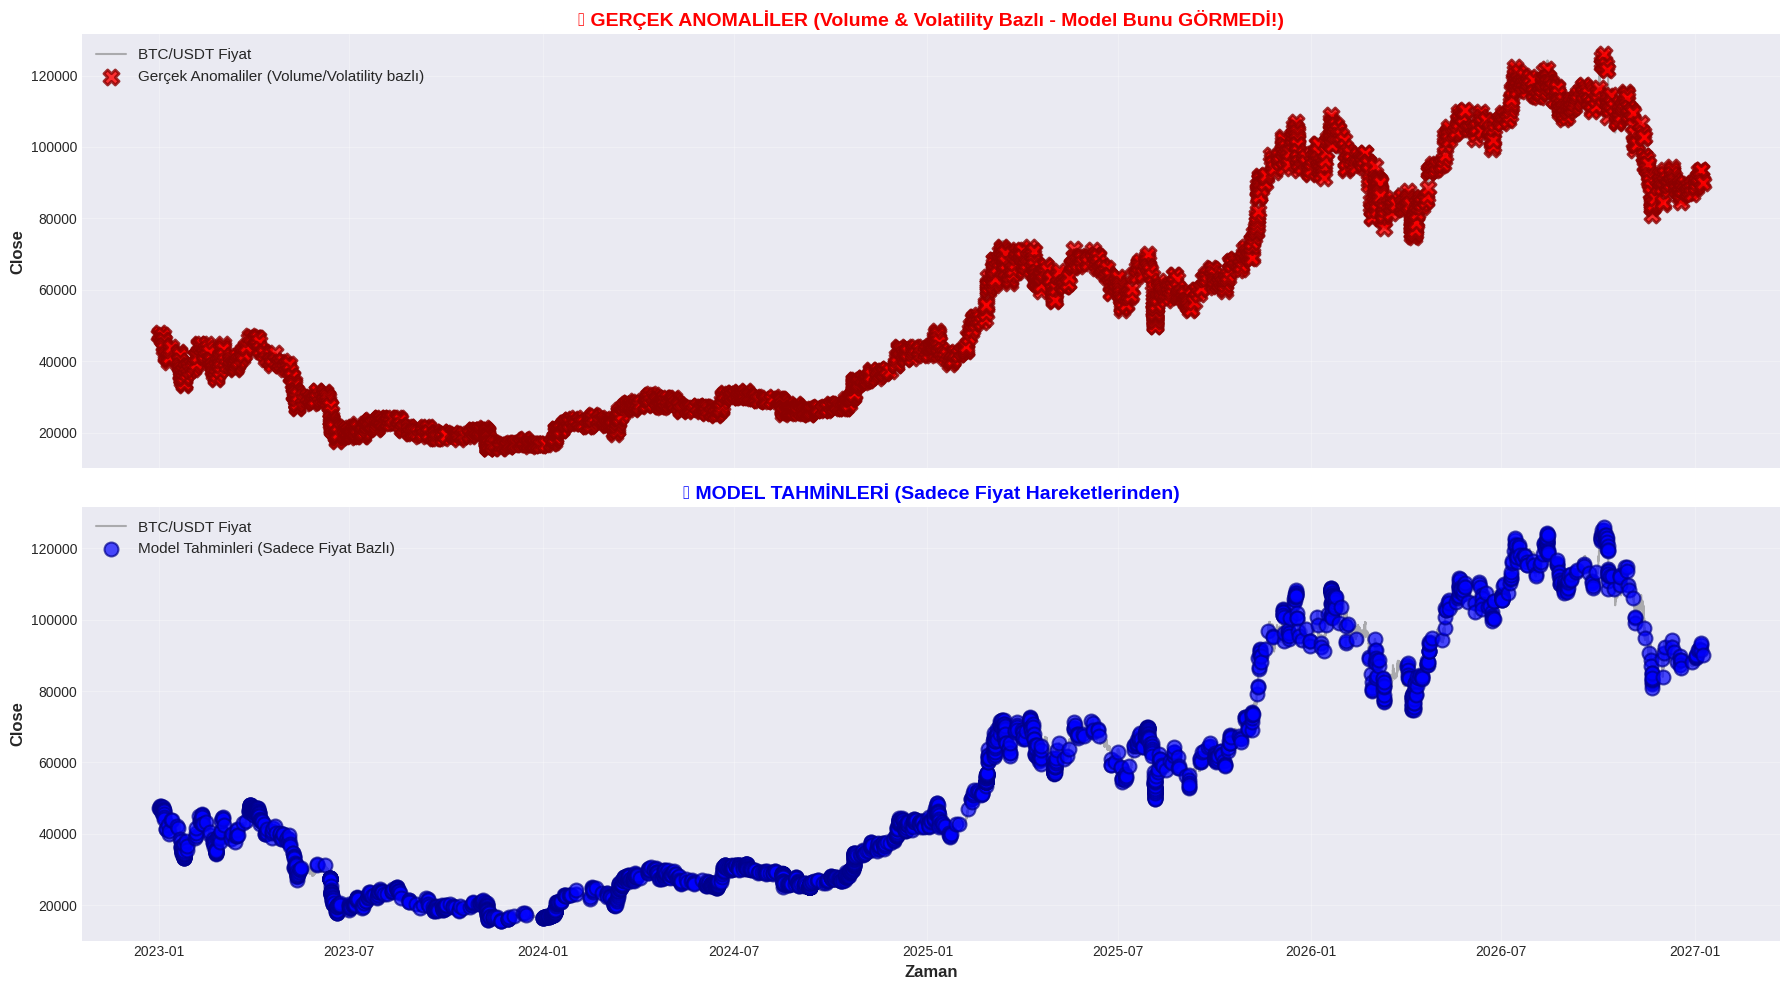


📊 ÖRTÜŞME ANALİZİ
🎯 Gerçek anomaliler (Volume/Vol bazlı): 2521
🤖 Model tahminleri (Fiyat bazlı): 2426
✅ Örtüşen anomaliler: 1064
🔍 Örtüşme Oranı (Gerçek anomalilere göre): 42.21%
🔍 Örtüşme Oranı (Tahmin edilen anomalilere göre): 43.86%

📊 GENEL CONFUSION MATRIX (Tüm pencereler)


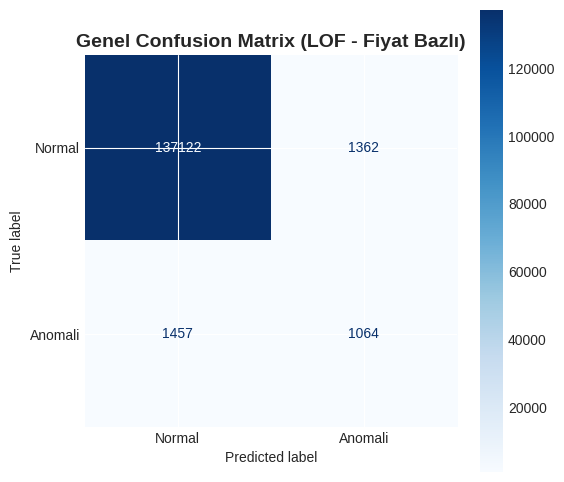


📊 METRİK KARŞILAŞTIRMA
    roc_auc  pr_auc  f1_score  precision  recall
17   0.9159  0.3831    0.4106     0.4386  0.4221


In [ ]:
# 1. Zaman Serisi: Gerçek vs Tahmin (Örtüşme Analizi)
def plot_leakage_free_comparison(df, predictions, feature_col=None):
    """
    Volume/Volatility bazlı gerçek anomaliler vs Fiyat bazlı tahminler
    """
    if feature_col is None:
        # Close fiyatını kullan
        close_cols = [col for col in df.columns if col.lower() == 'close']
        feature_col = close_cols[0] if len(close_cols) > 0 else training_features[0]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

    indices = predictions['indices']
    timestamps = predictions['timestamp']
    values = df.iloc[indices][feature_col].values

    # Üst grafik: Fiyat + Gerçek Anomaliler (Volume/Volatility bazlı)
    ax1.plot(timestamps, values, color='gray', alpha=0.6, linewidth=1.5, label='BTC/USDT Fiyat')

    true_anomaly_mask = np.array(predictions['y_true']) == 1
    ax1.scatter(np.array(timestamps)[true_anomaly_mask],
                values[true_anomaly_mask],
                color='red', s=120, marker='X', alpha=0.8,
                label='Gerçek Anomaliler (Volume/Volatility bazlı)',
                zorder=5, edgecolors='darkred', linewidths=2)

    ax1.set_ylabel(feature_col, fontsize=12, fontweight='bold')
    ax1.set_title('🎯 GERÇEK ANOMALİLER (Volume & Volatility Bazlı - Model Bunu GÖRMEDİ!)',
                  fontsize=14, fontweight='bold', color='red')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Alt grafik: Fiyat + Model Tahminleri (Sadece fiyat bazlı)
    ax2.plot(timestamps, values, color='gray', alpha=0.6, linewidth=1.5, label='BTC/USDT Fiyat')

    pred_anomaly_mask = np.array(predictions['y_pred']) == 1
    ax2.scatter(np.array(timestamps)[pred_anomaly_mask],
                values[pred_anomaly_mask],
                color='blue', s=100, marker='o', alpha=0.7,
                label='Model Tahminleri (Sadece Fiyat Bazlı)',
                zorder=5, edgecolors='darkblue', linewidths=1.5)

    ax2.set_xlabel('Zaman', fontsize=12, fontweight='bold')
    ax2.set_ylabel(feature_col, fontsize=12, fontweight='bold')
    ax2.set_title('🤖 MODEL TAHMİNLERİ (Sadece Fiyat Hareketlerinden)',
                  fontsize=14, fontweight='bold', color='blue')
    ax2.legend(loc='best', fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Örtüşme analizi
    overlap = np.sum(true_anomaly_mask & pred_anomaly_mask)
    total_true = np.sum(true_anomaly_mask)
    total_pred = np.sum(pred_anomaly_mask)

    print("\n" + "=" * 80)
    print("📊 ÖRTÜŞME ANALİZİ")
    print("=" * 80)
    print(f"🎯 Gerçek anomaliler (Volume/Vol bazlı): {total_true}")
    print(f"🤖 Model tahminleri (Fiyat bazlı): {total_pred}")
    print(f"✅ Örtüşen anomaliler: {overlap}")
    print(f"🔍 Örtüşme Oranı (Gerçek anomalilere göre): {overlap / total_true * 100:.2f}%")
    print(f"🔍 Örtüşme Oranı (Tahmin edilen anomalilere göre): {overlap / total_pred * 100:.2f}%")

# Karşılaştırmayı görselleştir
plot_leakage_free_comparison(df_clean, all_predictions, feature_col='Close')

# 2. Confusion Matrix ve Metrikler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomali"])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.show()

print("\n" + "=" * 80)
print("📊 GENEL CONFUSION MATRIX (Tüm pencereler)")
print("=" * 80)
plot_confusion_matrix(all_predictions['y_true'], all_predictions['y_pred'],
                      title="Genel Confusion Matrix (LOF - Fiyat Bazlı)")

# 3. Metrik Karşılaştırma (Opsiyonel: Diğer Modelleri Eklemek İçin)
# Şu an sadece LOF olduğu için doğrudan sonuçları kullanıyoruz
print("\n" + "=" * 80)
print("📊 METRİK KARŞILAŞTIRMA")
print("=" * 80)

metrics_df = results_df[results_df['window_id'] == 'OVERALL'][['roc_auc', 'pr_auc', 'f1_score', 'precision', 'recall']]
metrics_df = metrics_df.rename(index={'OVERALL': 'LOF_Model'})
print(metrics_df.round(4).to_string())


